# **Reduced Order Methods: an Introduction**

In this Lab we are going to introduce the main aspects of a parametric problem and the features that allow us to deal with it by means of Reduced Order Methods (ROMs).

First of all: ROMs are based on a Full Order Model (FOM). We can say also High Fidelity (HF) simulation.

Thus, we **need** a *standard* solver based on *standard discretizations*: in out case linear FE solvers.

Let us import the FOM library!

In [1]:
import numpy as np
import argparse
import os.path
import scipy.sparse
import vtk
from pypolydim import polydim, gedim
from pypolydim.export_vtk_utilities import ExportVTKUtilities
from pypolydim.assembler_utilities import assembler_utilities

import sys
sys.path.insert(1, '../')
import other_utilities as other_ut

In [2]:
geometry_utilities_config = gedim.GeometryUtilitiesConfig()
geometry_utilities_config.tolerance1_d = 1.0e-6
geometry_utilities_config.tolerance2_d = 1.0e-12
geometry_utilities = gedim.GeometryUtilities(geometry_utilities_config)
mesh_utilities = gedim.MeshUtilities()
vtk_utilities = ExportVTKUtilities()

## The parametric version of the heat conductivity equation

Solve the following equation on square ${\Omega} = (-1, +1) \times (-1, +1)$

$$
\begin{cases}
\nabla \cdot (k_{\mu} \nabla u) = 0 & \text{in } \Omega\\
k_{\mu} \nabla u \cdot n_1 = \mu_2 & \text{in } \Gamma_{base}\\
u = 0 & \text{in } \Gamma_{top}\\
k_{\mu} \nabla u \cdot n_2 = 0 & \text{otherwise} 
\end{cases}
$$

where $k_{\mu} = \mu_1$ if $x^2 + y^2 \leq R^2$ and $k = 1$ otherwise. 
The parametric space is $\mathcal P = [0.1, 10] \times [-1,1]$.

<img src="Images/ROM_problem1_domain.png" width=30% style="margin-left:auto; margin-right:auto">

The parameter $\boldsymbol \mu \in \mathcal P$ is physical and changes the features of the flow: 

1. $\mu_1$ the conductivity in $\Omega_1$;
2. $\mu_2$ describes the heat flux in the bottom part of the boundary.

First thing: we define two subdomains $\Omega_1$ and $\Omega_2$, such that
1. $\Omega_1$ is a disk in the origin with radius $r_0=0.5$, and
2. $\Omega_2=\Omega/\ \overline{\Omega_1}$.
3. $\Gamma_{base}$ to define where we will change the heat flux.

For a more exhaustive description of the problem refer to [this tutorial](https://colab.research.google.com/github/RBniCS/RBniCS/blob/open-in-colab/tutorials/01_thermal_block/tutorial_thermal_block.ipynb) based on [RBniCS library](https://www.rbnicsproject.org/).





**Define the High Fidelity Simulation Parameters**:
for a parametric problem we need not only the order of the discretization, but also the parametric space definition.



In [3]:
mesh_type = polydim.pde_tools.mesh.pde_mesh_utilities.MeshGenerator_Types_2D.csv_importer
method_type = polydim.pde_tools.local_space_pcc_2_d.MethodTypes.fem_pcc
import_mesh_folder = "./Test_Mesh" # Mesh2
method_order = 2

mu1_range = [0.1, 10.]
mu2_range = [-1., 1.]

### Import Mesh

In [4]:
#%%writefile ImportMesh.csv
#InputFolderPath
#../../CppToPython/Meshes/Mesh1

In [5]:
mesh_data = gedim.MeshMatrices()
mesh = gedim.MeshMatricesDAO(mesh_data)

polydim.pde_tools.mesh.pde_mesh_utilities.import_mesh_2_d(mesh_utilities,
                                                          mesh_type,
                                                          import_mesh_folder,
                                                          mesh)
mesh_geometric_data = polydim.pde_tools.mesh.pde_mesh_utilities.compute_mesh_2_d_geometry_data(geometry_utilities, mesh_utilities, mesh)

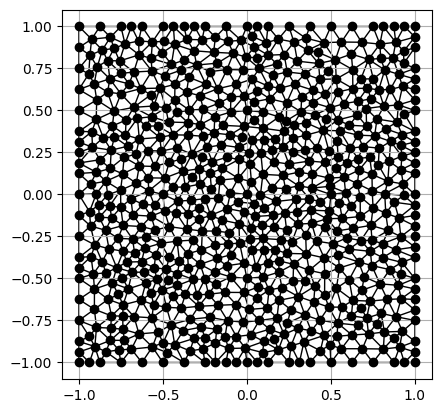

In [6]:
other_ut.plot_mesh(mesh)

**Create Discrete Space FEM (the FOM approximation)**

In [7]:
#### Labels \Gamma_down = 1 (neumann mu_2) , \Gamma_side = 2 (neumann 0) and \Gamma_top = 3 (dirichlet 0)
 
info_internal = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_internal.marker = 0

info_dirichlet_up = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.strong)
info_dirichlet_up.marker = 3

info_neumann_down = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.weak)
info_neumann_down.marker = 1

info_neumann_none = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_neumann_none.marker = 2

boundary_info = {
    0: info_internal,
    1: info_neumann_down,
    2: info_neumann_none,
    3: info_dirichlet_up
}

In [8]:
mesh_connectivity_data = polydim.pde_tools.mesh.MeshMatricesDAO_mesh_connectivity_data(mesh)

trial_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, method_order)
test_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, method_order)

dof_manager = polydim.pde_tools.do_fs.DOFsManager()

trial_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(trial_reference_element_data, mesh, boundary_info)
trial_dofs_data = dof_manager.create_do_fs_2_d(trial_mesh_dofs_info, mesh_connectivity_data)
test_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(trial_reference_element_data, mesh, boundary_info)
test_dofs_data = dof_manager.create_do_fs_2_d(test_mesh_dofs_info, mesh_connectivity_data)

### **Assemble linear system exploting affinity**

To have a better understanding of the _affine decomposition_ let us define the _weak formulation_ of the problem:
given $\boldsymbol \mu \in \mathcal P$, find the solution $u(\boldsymbol \mu)$ that solves


$$a\left(u(\boldsymbol{\mu}),v;\boldsymbol{\mu}\right)=f(v;\boldsymbol{\mu})\quad \forall v\in\mathbb{V}$$

where

* the function space is
$$
\mathbb{V} = \{v\in H^1(\Omega) : v|_{\Gamma_{top}}=0\},
$$
* the bilinear form $a(\cdot, \cdot; \boldsymbol{\mu}): \mathbb{V} \times \mathbb{V} \to \mathbb{R}$ is 
$$a(u, v;\boldsymbol{\mu})=\int_{\Omega} \kappa_\mu \nabla u\cdot \nabla v \ d\boldsymbol{x},$$
* the parametrized forcing term $f(\cdot; \boldsymbol{\mu}): \mathbb{V} \to \mathbb{R}$ is
$$f(v; \boldsymbol{\mu})= \mu_1\int_{\Gamma_{base}}v \ ds.$$

We want to compute the solution for **many** parameters in the parametric space.

Looking at the problem at hand, we notice that the system is _affine_!

Namely, it can be written as 
$$
\sum_{i=1}^{q_a} \theta_i^a(\boldsymbol \mu)a_i(u,v) = \sum_{i=0}^{q_f} \theta_i^f(\boldsymbol \mu)f_i(v),
$$
for $\theta_i^a(\boldsymbol \mu)$ and $\theta_i^f(\boldsymbol \mu)$ real functions and $q_a, q_f \in \mathbb N$.

Algebraic-wise

$$
\sum_{i=1}^{q_a} \theta_i^a(\boldsymbol \mu)\mathsf A_i = \sum_{i=0}^{q_f} \theta_i^f(\boldsymbol \mu)\mathsf f_i,
$$
where $\mathsf A_i$ and $\mathsf f_i$ are the assembled matrices and vectors of the system.


The separation of variables, i.e. $\boldsymbol \mu$-dependent and $\boldsymbol \mu$-independent quantities, is really useful to divide the ROM process following the _offline_-_online_ paradigm (more details in the next Lab).

For now, let us focus on the FOM parametric version. Our problem is affine-decomposed in

$$a(u,v;\boldsymbol{\mu})=\underbrace{\mu_1}_{\Theta^{a}_1(\boldsymbol{\mu})}\underbrace{\int_{\Omega_1}\nabla u \cdot \nabla v \ d\boldsymbol{x}}_{a_1(u,v)} \ + \  \underbrace{1}_{\Theta^{a}_2(\boldsymbol{\mu})}\underbrace{\int_{\Omega_2}\nabla u \cdot \nabla v \ d\boldsymbol{x}}_{a_2(u,v)},$$
$$f(v; \boldsymbol{\mu}) = \underbrace{\mu_2}_{\Theta^{f}_1(\boldsymbol{\mu})} \underbrace{\int_{\Gamma_{base}}v \ ds}_{f_1(v)}.$$




Let us define $\theta_i^a(\boldsymbol \mu)$ and $\theta_1^f(\boldsymbol \mu)$, for $i \in \{1,2\}$ with some numbers in the parametric range. 

In [9]:
thetaA1 = 1.
thetaA2 = 6.68
thetaf1 = 0.94

Let us define $a_1(u,v)$, $a_2(u,v)$ and $f(v)$,

In [10]:
R = 0.5

def omega_1(x, y, z):
    if (x * x + y * y) <= (R * R + 1.0e-13):
        return 1.0
    return 0.0

A_omega_1 = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(geometry_utilities,
                                                                                      mesh,
                                                                                      mesh_geometric_data,
                                                                                      trial_dofs_data,
                                                                                      test_dofs_data,
                                                                                      trial_reference_element_data,
                                                                                      test_reference_element_data,
                                                                                      omega_1)


A_1 = other_ut.make_np_sparse(A_omega_1.operator_dofs)
A_1_D = other_ut.make_np_sparse(A_omega_1.operator_strong)

def omega_2(x, y, z):
    if (x * x + y * y) <= (R * R + 1.0e-13):
        return 0.0
    return 1.0

A_omega_2 = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(geometry_utilities,
                                                                                      mesh,
                                                                                      mesh_geometric_data,
                                                                                      trial_dofs_data,
                                                                                      test_dofs_data,
                                                                                      trial_reference_element_data,
                                                                                      test_reference_element_data,
                                                                                      omega_2)


A_2 = other_ut.make_np_sparse(A_omega_2.operator_dofs)
A_2_D = other_ut.make_np_sparse(A_omega_2.operator_strong)

def weak_term_function(marker, x, y, z):
    match marker:
        case 1:
            return 1.0
        case _:
            raise ValueError("not valid marker", marker)


weak_term = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_weak_term(geometry_utilities,
                                                                             mesh,
                                                                             mesh_geometric_data,
                                                                             trial_mesh_dofs_info,
                                                                             test_dofs_data,
                                                                             trial_reference_element_data,
                                                                             test_reference_element_data,
                                                                             weak_term_function)

def strong_solution_function(marker, x, y, z):  
    return 0.0

u_D = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       trial_mesh_dofs_info,
                                                                       trial_dofs_data,
                                                                       trial_reference_element_data,
                                                                       strong_solution_function)

AttributeError: 'csc_array' object has no attribute 'operator_strong'

and, finally, let us solve $a(u,v; \boldsymbol \mu) = f(v; \boldsymbol \mu)$.

In [ ]:
a_mu = thetaA1*A_1 + thetaA2*A_2
f_mu = thetaf1*weak_term

In [ ]:
u = scipy.sparse.linalg.spsolve(a_mu, f_mu)

In [ ]:
u_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                                          trial_dofs_data,
                                                                                          u,
                                                                                          u_D)
other_ut.plot_solution(mesh, u_on_cell0Ds.numeric_solution) 

## **Let us do another exercise together** ##

Solve the following equation on square ${\Omega} = (-1, +1) \times (-1, +1)$

$$
\begin{cases}
\nabla \cdot (k_{\mu} \nabla u) + \beta_\mu x(1-x) \frac {\partial}{\partial x}u = f & \text{in } \Omega\\
u = 0 & \text{in } \Gamma_{top}\\
k_{\mu} \nabla u \cdot n_2 = 0 & \text{otherwise} 
\end{cases}
$$

where $k_\mu = \mu_i \in \Omega_i$ and $\beta_\mu = \mu_{4 + i} \in \Omega_i$ for $i \in \{1, \dots, 4\}$
The parametric space is $\mathcal P = [0.1, 5]^4 \times [1, 10]^4$. The forcing term is $f \equiv 10$.

<img src="Images/ROMex.png" width=30% style="margin-left:auto; margin-right:auto">





Let us define the nodes of the boundary and the subdomains.


In [ ]:
def Poisson_f(numPoints, points):
	values = 10*np.ones(numPoints)
	return values.ctypes.data

def Omega1_stiff(numPoints, points):
	matPoints = gedim.make_nd_matrix(points, (3, numPoints), np.double)
	values = np.zeros(numPoints)
	for p in range(0, numPoints):
		if ((matPoints[0,p]) <= 0) & ((matPoints[1,p])<= 0.):
			values[p] = 1. 
	return values.ctypes.data  

def Omega1_adv(numPoints, points):
	matPoints = gedim.make_nd_matrix(points, (3, numPoints), np.double)
	values = np.zeros(numPoints)
	for p in range(0, numPoints):
		if ((matPoints[0,p]) <= 0.) & ((matPoints[1,p]) <= 0.):
			values[p] = (matPoints[0,p] * (1.0 - matPoints[0,p]))
	return values.ctypes.data  

def Omega2_stiff(numPoints, points):
	matPoints = gedim.make_nd_matrix(points, (3, numPoints), np.double)
	values = np.zeros(numPoints)
	for p in range(0, numPoints):
		if ((matPoints[0,p]) > 0.) & ((matPoints[1,p])<= 0.):
			values[p] = 1.
	return values.ctypes.data  

def Omega2_adv(numPoints, points):
	matPoints = gedim.make_nd_matrix(points, (3, numPoints), np.double)
	values = np.zeros(numPoints)
	for p in range(0, numPoints):
		if ((matPoints[0,p]) > 0.) & ((matPoints[1,p])<= 0.):
			values[p] = (matPoints[0,p] * (1.0 - matPoints[0,p]))
	return values.ctypes.data  


def Omega3_stiff(numPoints, points):
	matPoints = gedim.make_nd_matrix(points, (3, numPoints), np.double)
	values = np.zeros(numPoints)
	for p in range(0, numPoints):
		if ((matPoints[0,p]) <= 0) & ((matPoints[1,p])> 0.):
			values[p] = 1. ### qui cambia
	return values.ctypes.data  

def Omega3_adv(numPoints, points):
	matPoints = gedim.make_nd_matrix(points, (3, numPoints), np.double)
	values = np.zeros(numPoints)
	for p in range(0, numPoints):
		if ((matPoints[0,p]) <= 0) & ((matPoints[1,p])> 0.):
			values[p] = (matPoints[0,p] * (1.0 - matPoints[0,p]))
	return values.ctypes.data  

def Omega4_stiff(numPoints, points):
	matPoints = gedim.make_nd_matrix(points, (3, numPoints), np.double)
	values = np.zeros(numPoints)
	for p in range(0, numPoints):
		if ((matPoints[0,p]) > 0.) & ((matPoints[1,p]) > 0.):
			values[p] = 1. ### qui cambia
	return values.ctypes.data  

def Omega4_adv(numPoints, points):
	matPoints = gedim.make_nd_matrix(points, (3, numPoints), np.double)
	values = np.zeros(numPoints)
	for p in range(0, numPoints):
		if ((matPoints[0,p]) > 0.) & ((matPoints[1,p]) > 0.):
			values[p] = (matPoints[0,p] * (1.0 - matPoints[0,p]))
	return values.ctypes.data 


Also in this case we have an affine decomposition:

$$a(u,v;\boldsymbol{\mu})=
\sum_{i = 1}^4 \underbrace{\mu_i}_{\Theta^{a}_i(\boldsymbol{\mu}) \text{ for } i \in \{1, \dots, 4\}}\underbrace{\int_{\Omega_i}\nabla u \cdot \nabla v \ d\boldsymbol{x}}_{a_i(u,v) \text{ for } i \in \{1, \dots, 4\}} \ + \sum_{i = 5}^8 \underbrace{\mu_i}_{\Theta^{a}_i(\boldsymbol{\mu}) \text{ for } i \in \{5, \dots, 8\}}\underbrace{\int_{\Omega_i}x(1-x)\frac{\partial}{\partial x} u \cdot v \ d\boldsymbol{x}}_{a_i(u,v) \text{ for } i \in \{5, \dots, 8\}}$$
$$f(v; \boldsymbol{\mu}) = 10\underbrace{\int_{\Omega}v \ ds}_{f_1(v)}.$$

Let us define the bilinear forms and the forcing term.

In [ ]:
[stiffness1, stiffnessStrong1] = gedim.AssembleStiffnessMatrix(Omega1_stiff, problemData, lib)
[stiffness2, stiffnessStrong2] = gedim.AssembleStiffnessMatrix(Omega2_stiff, problemData, lib)
[stiffness3, stiffnessStrong3] = gedim.AssembleStiffnessMatrix(Omega3_stiff, problemData, lib)
[stiffness4, stiffnessStrong4] = gedim.AssembleStiffnessMatrix(Omega4_stiff, problemData, lib)

[advection1, advectionStrong1] = gedim.AssembleAdvectionMatrix(Omega1_adv, problemData, lib)
[advection2, advectionStrong2] = gedim.AssembleAdvectionMatrix(Omega2_adv, problemData, lib)
[advection3, advectionStrong3] = gedim.AssembleAdvectionMatrix(Omega3_adv, problemData, lib)
[advection4, advectionStrong4] = gedim.AssembleAdvectionMatrix(Omega4_adv, problemData, lib)

forcingTerm = gedim.AssembleForcingTerm(Poisson_f, problemData, lib)


Let us define the ``thetas``.

In [ ]:
#thetas
thetaA1 = 1
thetaA2 = 2
thetaA3 = 3
thetaA4 = 4
thetaA5 = 10
thetaA6 = 10
thetaA7 = 1
thetaA8 = 10
   

In [ ]:
stiffness = thetaA1*stiffness1  + thetaA2*stiffness2 + thetaA3*stiffness3 + thetaA4*stiffness4
advection = thetaA5*advection1 + thetaA6*advection2 + thetaA7*advection3 + thetaA8*advection4
 
lhs = stiffness + advection

In [ ]:
stiffnessStrong = thetaA1*stiffnessStrong1 + thetaA2*stiffnessStrong2 + thetaA3*stiffnessStrong3 + thetaA4*stiffnessStrong4
advectionStrong = thetaA5*advectionStrong1 + thetaA6*advectionStrong2 + thetaA7*advectionStrong3 + thetaA8*advectionStrong4

rhs = forcingTerm

Finally, let us solve the system.

In [ ]:
solution = gedim.LUSolver(lhs, rhs, lib)

In [ ]:
gedim.PlotSolution(mesh, dofs, strongs, solution, np.zeros(problemData['NumberStrongs']))

Solve the same problem with $u=2$ on $\Gamma_{top}$.

In [ ]:
######################## Define the boundary condition as a vector of 2 #####################

def Dirichlet_BoundaryTerm(numPoints, points):
	values = 2*np.ones(numPoints)
	return values.ctypes.data

############################################################################################

def Poisson_f(numPoints, points):
	values = 10*np.ones(numPoints)
	return values.ctypes.data

def Omega1_stiff(numPoints, points):
	matPoints = gedim.make_nd_matrix(points, (3, numPoints), np.double)
	values = np.zeros(numPoints)
	for p in range(0, numPoints):
		if ((matPoints[0,p]) <= 0) & ((matPoints[1,p])<= 0.):
			values[p] = 1. 
	return values.ctypes.data  

def Omega1_adv(numPoints, points):
	matPoints = gedim.make_nd_matrix(points, (3, numPoints), np.double)
	values = np.zeros(numPoints)
	for p in range(0, numPoints):
		if ((matPoints[0,p]) <= 0.) & ((matPoints[1,p]) <= 0.):
			values[p] = (matPoints[0,p] * (1.0 - matPoints[0,p]))
	return values.ctypes.data  

def Omega2_stiff(numPoints, points):
	matPoints = gedim.make_nd_matrix(points, (3, numPoints), np.double)
	values = np.zeros(numPoints)
	for p in range(0, numPoints):
		if ((matPoints[0,p]) > 0.) & ((matPoints[1,p])<= 0.):
			values[p] = 1.
	return values.ctypes.data  

def Omega2_adv(numPoints, points):
	matPoints = gedim.make_nd_matrix(points, (3, numPoints), np.double)
	values = np.zeros(numPoints)
	for p in range(0, numPoints):
		if ((matPoints[0,p]) > 0.) & ((matPoints[1,p])<= 0.):
			values[p] = (matPoints[0,p] * (1.0 - matPoints[0,p]))
	return values.ctypes.data  


def Omega3_stiff(numPoints, points):
	matPoints = gedim.make_nd_matrix(points, (3, numPoints), np.double)
	values = np.zeros(numPoints)
	for p in range(0, numPoints):
		if ((matPoints[0,p]) <= 0) & ((matPoints[1,p])> 0.):
			values[p] = 1. ### qui cambia
	return values.ctypes.data  

def Omega3_adv(numPoints, points):
	matPoints = gedim.make_nd_matrix(points, (3, numPoints), np.double)
	values = np.zeros(numPoints)
	for p in range(0, numPoints):
		if ((matPoints[0,p]) <= 0) & ((matPoints[1,p])> 0.):
			values[p] = (matPoints[0,p] * (1.0 - matPoints[0,p]))
	return values.ctypes.data  

def Omega4_stiff(numPoints, points):
	matPoints = gedim.make_nd_matrix(points, (3, numPoints), np.double)
	values = np.zeros(numPoints)
	for p in range(0, numPoints):
		if ((matPoints[0,p]) > 0.) & ((matPoints[1,p]) > 0.):
			values[p] = 1. ### qui cambia
	return values.ctypes.data  

def Omega4_adv(numPoints, points):
	matPoints = gedim.make_nd_matrix(points, (3, numPoints), np.double)
	values = np.zeros(numPoints)
	for p in range(0, numPoints):
		if ((matPoints[0,p]) > 0.) & ((matPoints[1,p]) > 0.):
			values[p] = (matPoints[0,p] * (1.0 - matPoints[0,p]))
	return values.ctypes.data 


Also in this case we have an affine decomposition:

$$a(u,v;\boldsymbol{\mu})=
\sum_{i = 1}^4 \underbrace{\mu_i}_{\Theta^{a}_i(\boldsymbol{\mu}) \text{ for } i \in \{1, \dots, 4\}}\underbrace{\int_{\Omega_i}\nabla u \cdot \nabla v \ d\boldsymbol{x}}_{a_i(u,v) \text{ for } i \in \{5, \dots, 8\}} \ + \sum_{i = 1}^4 \underbrace{\mu_i}_{\Theta^{a}_i(\boldsymbol{\mu}) \text{ for } i \in \{5, \dots, 8\}}\underbrace{\int_{\Omega_i}x(1-x)\frac{\partial}{\partial x} u \cdot v \ d\boldsymbol{x}}_{a_i(u,v) \text{ for } i \in \{1, \dots, 4\}}$$
$$f(v; \boldsymbol{\mu}) = {10} \underbrace{\int_{\Omega}v \ ds}_{f_1(v)}.$$

Let us define the bilinear forms and the forcing term.

In [ ]:
[stiffness1, stiffnessStrong1] = gedim.AssembleStiffnessMatrix(Omega1_stiff, problemData, lib)
[stiffness2, stiffnessStrong2] = gedim.AssembleStiffnessMatrix(Omega2_stiff, problemData, lib)
[stiffness3, stiffnessStrong3] = gedim.AssembleStiffnessMatrix(Omega3_stiff, problemData, lib)
[stiffness4, stiffnessStrong4] = gedim.AssembleStiffnessMatrix(Omega4_stiff, problemData, lib)

[advection1, advectionStrong1] = gedim.AssembleAdvectionMatrix(Omega1_adv, problemData, lib)
[advection2, advectionStrong2] = gedim.AssembleAdvectionMatrix(Omega2_adv, problemData, lib)
[advection3, advectionStrong3] = gedim.AssembleAdvectionMatrix(Omega3_adv, problemData, lib)
[advection4, advectionStrong4] = gedim.AssembleAdvectionMatrix(Omega4_adv, problemData, lib)

forcingTerm = gedim.AssembleForcingTerm(Poisson_f, problemData, lib)

#### computing the boundary condition. ATTENTION: 3 is the label of the mesh, in out case is \Gamma_down = 1, \Gamma_side = 2 and \Gamma_top = 3
DirichletTerm = gedim.AssembleStrongSolution(Dirichlet_BoundaryTerm, 3, problemData, lib)
####


Let us define the ``thetas``.

In [ ]:
#thetas
thetaA1 = 1
thetaA2 = 2
thetaA3 = 3
thetaA4 = 4
thetaA5 = 10
thetaA6 = 10
thetaA7 = 1
thetaA8 = 10
# thetaf1 = already assembled    

In [ ]:
stiffness = thetaA1*stiffness1  + thetaA2*stiffness2 + thetaA3*stiffness3 + thetaA4*stiffness4
advection = thetaA5*advection1 + thetaA6*advection2 + thetaA7*advection3 + thetaA8*advection4
 
lhs = stiffness + advection

In [ ]:
stiffnessStrong = thetaA1*stiffnessStrong1 + thetaA2*stiffnessStrong2 + thetaA3*stiffnessStrong3 + thetaA4*stiffnessStrong4
advectionStrong = thetaA5*advectionStrong1 + thetaA6*advectionStrong2 + thetaA7*advectionStrong3 + thetaA8*advectionStrong4

######### Change the RHS with the dirichlet term 
rhs = forcingTerm - (stiffnessStrong + advectionStrong ) @ DirichletTerm 
################

Finally, let us solve the system.

In [ ]:
solution = gedim.LUSolver(lhs, rhs, lib)
print(max(solution))

In [ ]:
gedim.PlotSolution(mesh, dofs, strongs, solution, DirichletTerm) ### the last argument is the Dirichlet term